# 05 Model Comparison - Rolling Backtest 24h

## Goal
Compare all models under the same protocol:
- train history from 2019
- rolling daily backtest over 2025
- `h=24` day-ahead forecasts
- same evaluation metrics: RMSE, MAE, MAPE

## Expected input files
`../../artifacts/model_results/*_metrics_rolling_24h.csv` and `*_predictions_rolling_24h.csv`

Current notebooks that can produce these files:
- `05_TimeGPT_Nixtla.ipynb` (can be extended to export)
- `05_model_XGBoost_rolling_backtest_24h.ipynb` (can be extended to export)
- `05_model_lstm_rolling_backtest_24h.ipynb` (can be extended to export)
- `05_model_arimax_rolling_backtest_24h.ipynb`
- `05_model_sarimax_rolling_backtest_24h.ipynb`
- `05_model_timegpt_rolling_backtest_24h.ipynb`

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [4]:
# Load available metrics
root = Path('../../artifacts/model_results')
metric_files = sorted(root.glob('*_metrics_rolling_24h.csv'))
print('Found metric files:')
for f in metric_files:
    print('-', f.name)
if not metric_files:
    raise ValueError('No metric files found. Run model notebooks first.')

metrics = pd.concat([pd.read_csv(f) for f in metric_files], ignore_index=True)
metrics = metrics.sort_values('rmse').reset_index(drop=True)
metrics


Found metric files:
- arimax_retrainm_metrics_rolling_24h.csv
- lstm_retrainm_metrics_rolling_24h.csv
- mlforecast_xgb_retrainm_metrics_rolling_24h.csv
- timegpt_focus_janfeb2025_metrics_rolling_24h.csv
- xgboost_retrainm_metrics_rolling_24h.csv


,model,rmse,mae,smape,mape_filtered_abs_ge_10,n_predictions
0,XGBoost_retrainM,24.535580,15.017468,16.074290,12.867319,1416
1,MLForecast_XGB_retrainM,26.610584,15.148787,15.737970,13.499365,1416
2,ARIMAX_retrainM,27.503259,18.462715,39.470008,22.426967,8736
3,TimeGPT_focusJanFeb2025,47.428136,30.346606,31.226532,24.382878,1416
4,LSTM_retrainM,301.985150,196.008929,96.760523,169.998767,1416


In [5]:
# Leaderboard
# prefer robust metrics for this domain: rmse, mae, smape
preferred = ['model', 'rmse', 'mae', 'smape', 'mape_filtered_abs_ge_10', 'n_predictions']
display_cols = [c for c in preferred if c in metrics.columns]
leaderboard = metrics[display_cols].copy().sort_values('rmse')
leaderboard


,model,rmse,mae,smape,mape_filtered_abs_ge_10,n_predictions
0,XGBoost_retrainM,24.535580,15.017468,16.074290,12.867319,1416
1,MLForecast_XGB_retrainM,26.610584,15.148787,15.737970,13.499365,1416
2,ARIMAX_retrainM,27.503259,18.462715,39.470008,22.426967,8736
3,TimeGPT_focusJanFeb2025,47.428136,30.346606,31.226532,24.382878,1416
4,LSTM_retrainM,301.985150,196.008929,96.760523,169.998767,1416


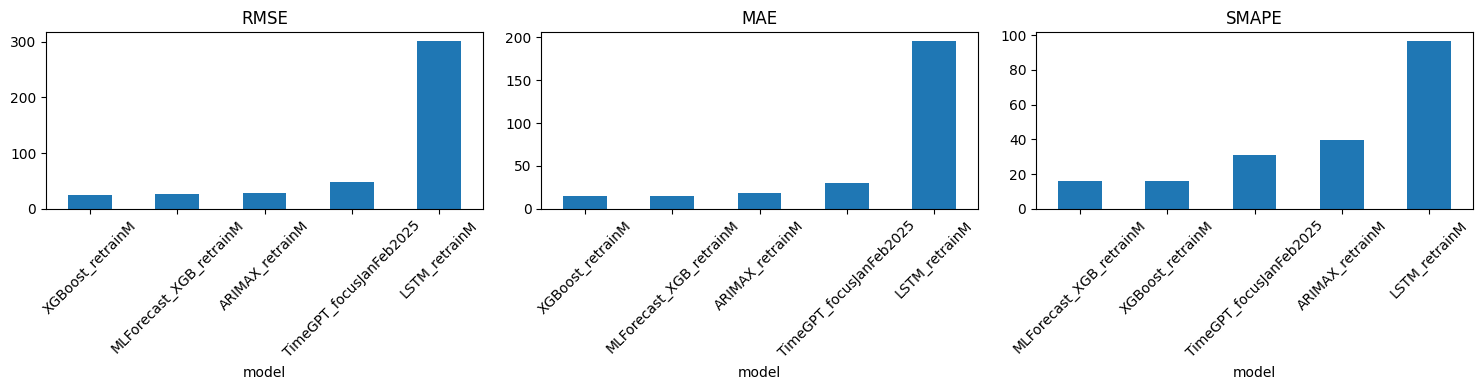

In [6]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
leaderboard.sort_values('rmse').plot.bar(x='model', y='rmse', ax=axes[0], legend=False, title='RMSE')
leaderboard.sort_values('mae').plot.bar(x='model', y='mae', ax=axes[1], legend=False, title='MAE')
metric3 = 'smape' if 'smape' in leaderboard.columns else ('mape' if 'mape' in leaderboard.columns else None)
if metric3 is None:
    raise ValueError('Neither smape nor mape found in metrics files.')
leaderboard.sort_values(metric3).plot.bar(x='model', y=metric3, ax=axes[2], legend=False, title=metric3.upper())
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [7]:
# Optional: merge prediction files for aligned visual check
pred_files = sorted(root.glob('*_predictions_rolling_24h.csv'))
print('Found prediction files:')
for f in pred_files:
    print('-', f.name)

frames = []
for f in pred_files:
    p = pd.read_csv(f)
    model_name = f.name.replace('_predictions_rolling_24h.csv', '').upper()
    p['model'] = model_name
    frames.append(p)

if frames:
    all_preds = pd.concat(frames, ignore_index=True)
    all_preds['ds'] = pd.to_datetime(all_preds['ds'])
    print(all_preds[['model', 'ds', 'actual', 'prediction']].head())
else:
    all_preds = pd.DataFrame()
    print('No prediction files available yet.')


Found prediction files:
- arimax_retrainm_predictions_rolling_24h.csv
- lstm_retrainm_predictions_rolling_24h.csv
- mlforecast_xgb_retrainm_predictions_rolling_24h.csv
- timegpt_focus_janfeb2025_predictions_rolling_24h.csv
- xgboost_retrainm_predictions_rolling_24h.csv
             model                  ds  actual  prediction
0  ARIMAX_RETRAINM 2025-01-01 00:00:00    1.60  -41.870123
1  ARIMAX_RETRAINM 2025-01-01 01:00:00    0.00  -47.093038
2  ARIMAX_RETRAINM 2025-01-01 02:00:00   -0.01  -48.181191
3  ARIMAX_RETRAINM 2025-01-01 03:00:00   -0.01  -49.711322
4  ARIMAX_RETRAINM 2025-01-01 04:00:00   -0.06  -49.849658


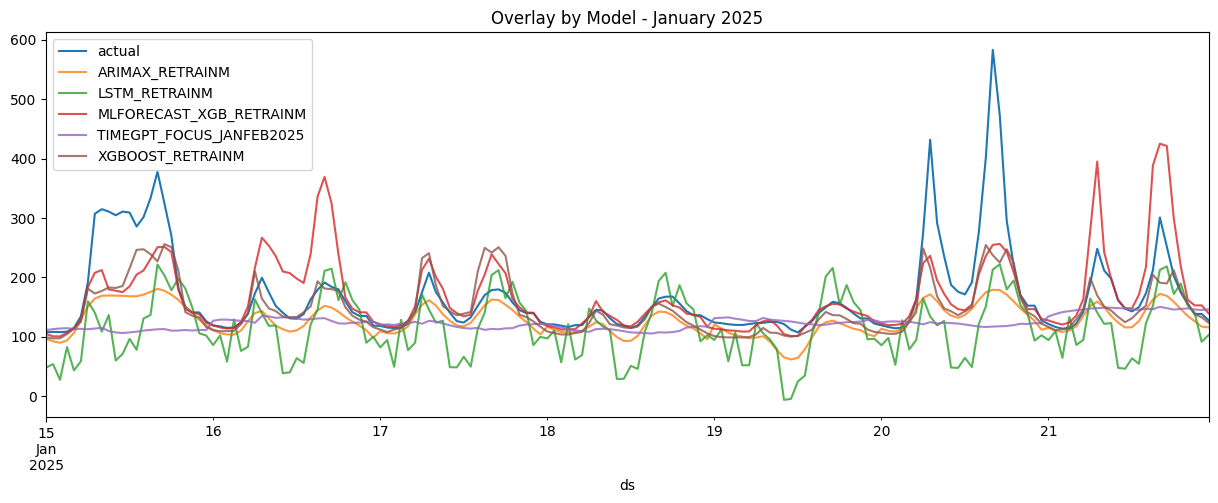

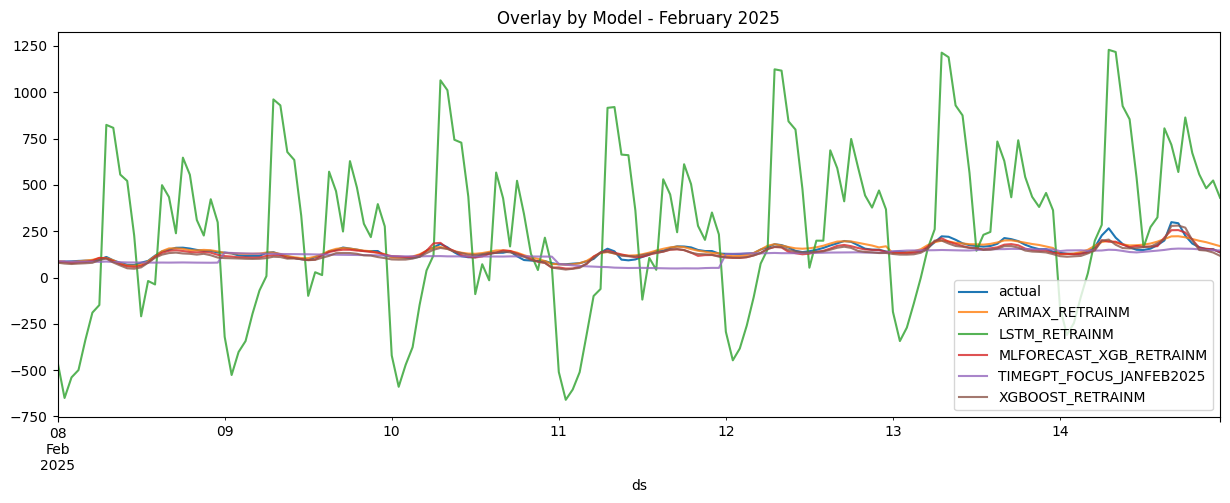

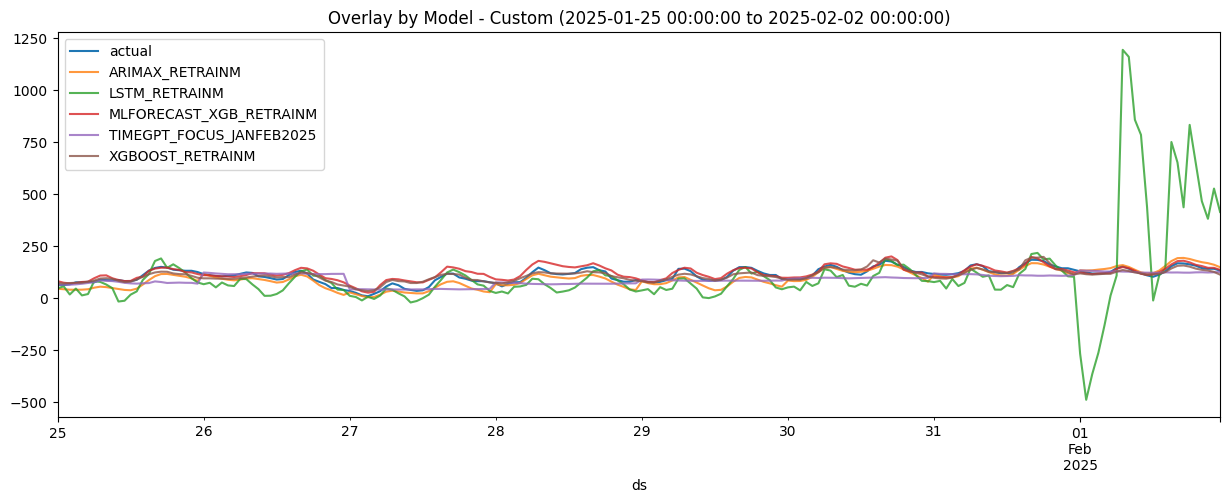

In [8]:
# Plot overlays: January, February, and adjustable custom range

def plot_overlay(all_preds, start, end, title):
    z = all_preds[(all_preds['ds'] >= pd.Timestamp(start)) & (all_preds['ds'] < pd.Timestamp(end))].copy()
    if z.empty:
        print(f'No predictions in range {start} -> {end}')
        return

    actual = z[['ds', 'actual']].drop_duplicates().sort_values('ds').set_index('ds')
    ax = actual.plot(figsize=(15, 5), title=title)

    plotted_models = []
    for model, g in z.groupby('model'):
        g = g.sort_values('ds').set_index('ds')
        if g.empty:
            continue
        g['prediction'].plot(ax=ax, alpha=0.8)
        plotted_models.append(model)

    ax.legend(['actual'] + sorted(plotted_models))
    plt.show()

if all_preds.empty:
    print('No predictions to plot yet.')
else:
    # 1) January fixed window
    jan_start = '2025-01-15 00:00:00'
    jan_end = '2025-01-22 00:00:00'
    plot_overlay(all_preds, jan_start, jan_end, 'Overlay by Model - January 2025')

    # 2) February fixed window
    feb_start = '2025-02-08 00:00:00'
    feb_end = '2025-02-15 00:00:00'
    plot_overlay(all_preds, feb_start, feb_end, 'Overlay by Model - February 2025')

    # 3) Custom adjustable window
    custom_start = '2025-01-25 00:00:00'  # change as needed
    custom_end = '2025-02-02 00:00:00'    # change as needed
    plot_overlay(all_preds, custom_start, custom_end, f'Overlay by Model - Custom ({custom_start} to {custom_end})')


## Best-practice comparison checklist
1. Ensure each model uses identical cutoffs and horizon (`h=24`).
2. Verify exogenous inputs obey day-ahead availability assumptions.
3. Compare both error metrics and runtime.
4. Decide final model on both quality and operational cost, not metric alone.